<a href="https://colab.research.google.com/github/YashhCanCode/Spam_Classifier/blob/main/Spam_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv('spam.csv', encoding= 'latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
print(df.shape)
print(df['label'].value_counts())

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


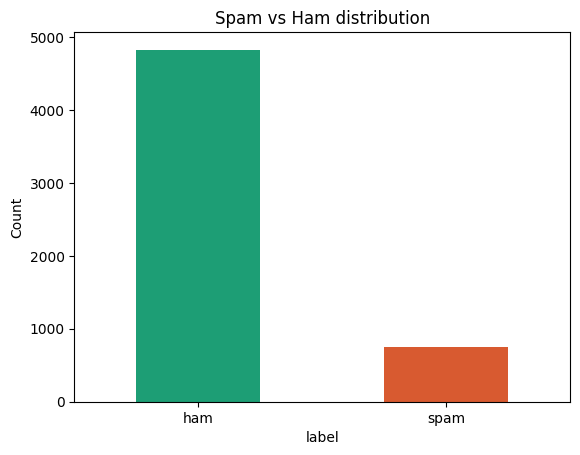

In [ ]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', color=['#1D9E75', '#D85A30'])
plt.title('Spam vs Ham distribution')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.show()

In [ ]:
df['message_length'] = df['message'].apply(len)
print(df.groupby('label')['message_length'].mean())

label
ham      71.023627
spam    138.866131
Name: message_length, dtype: float64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

print(df[['label', 'label_encoded']].drop_duplicates())

  label  label_encoded
0   ham              0
2  spam              1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['message']
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training set size:", X_train_tfidf.shape)
print("Test set size:", X_test_tfidf.shape)

Training set size: (4457, 3000)
Test set size: (1115, 3000)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Model 1 — Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Model 2 — Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

print("Both models trained successfully")

Both models trained successfully


In [ ]:
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, ConfusionMatrixDisplay)

# Predictions
nb_preds = nb_model.predict(X_test_tfidf)
lr_preds = lr_model.predict(X_test_tfidf)

# AUC scores
nb_auc = roc_auc_score(y_test, nb_model.predict_proba(X_test_tfidf)[:,1])
lr_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test_tfidf)[:,1])

print(f"Naive Bayes AUC:          {nb_auc:.4f}")
print(f"Logistic Regression AUC:  {lr_auc:.4f}")

Naive Bayes AUC:          0.9890
Logistic Regression AUC:  0.9863


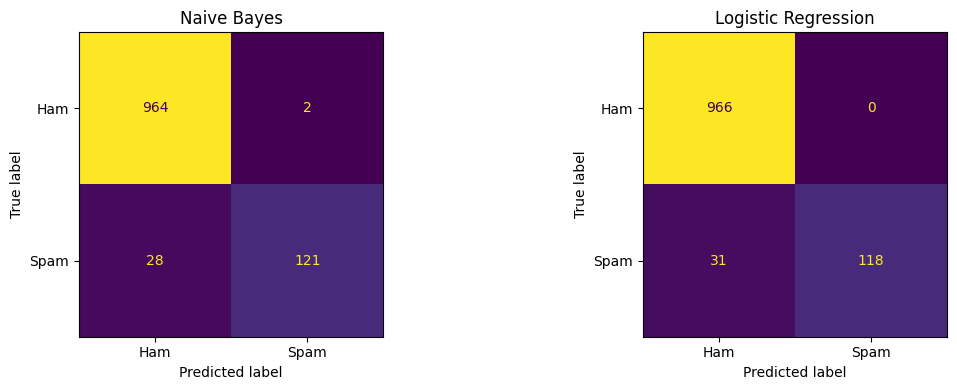

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, nb_preds, display_labels=['Ham', 'Spam'],
    ax=axes[0], colorbar=False
)
axes[0].set_title('Naive Bayes')

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_preds, display_labels=['Ham', 'Spam'],
    ax=axes[1], colorbar=False
)
axes[1].set_title('Logistic Regression')

plt.tight_layout()
plt.show()

In [ ]:
print("NAIVE BAYES")
print(classification_report(y_test, nb_preds, target_names=['Ham', 'Spam']))

print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr_preds, target_names=['Ham', 'Spam']))

NAIVE BAYES
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.98      0.81      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.97      0.97      0.97      1115

LOGISTIC REGRESSION
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [ ]:
def predict_message(message):
    message_tfidf = tfidf.transform([message])
    nb_pred = nb_model.predict(message_tfidf)[0]
    lr_pred = lr_model.predict(message_tfidf)[0]
    nb_prob = nb_model.predict_proba(message_tfidf)[0][1]
    lr_prob = lr_model.predict_proba(message_tfidf)[0][1]

    print(f"Message: {message}")
    print(f"Naive Bayes:          {'SPAM' if nb_pred==1 else 'HAM'} (confidence: {nb_prob:.2%})")
    print(f"Logistic Regression:  {'SPAM' if lr_pred==1 else 'HAM'} (confidence: {lr_prob:.2%})")
    print()

predict_message("Congratulations! You won a free iPhone. Click here to claim now!")
predict_message("Hey are we still meeting for lunch tomorrow?")
predict_message("URGENT: Your bank account has been compromised. Call us immediately.")
predict_message("Can you send me the notes from today's class?")

Message: Congratulations! You won a free iPhone. Click here to claim now!
Naive Bayes:          SPAM (confidence: 90.82%)
Logistic Regression:  SPAM (confidence: 76.76%)

Message: Hey are we still meeting for lunch tomorrow?
Naive Bayes:          HAM (confidence: 0.31%)
Logistic Regression:  HAM (confidence: 2.17%)

Message: URGENT: Your bank account has been compromised. Call us immediately.
Naive Bayes:          SPAM (confidence: 55.33%)
Logistic Regression:  HAM (confidence: 39.47%)

Message: Can you send me the notes from today's class?
Naive Bayes:          HAM (confidence: 1.94%)
Logistic Regression:  HAM (confidence: 6.55%)



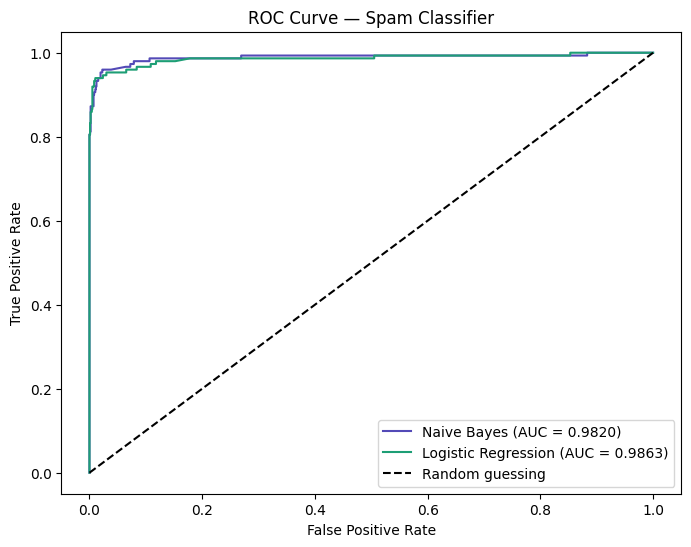

In [ ]:
from sklearn.metrics import roc_curve

nb_probs = nb_model.predict_proba(X_test_tfidf)[:,1]
lr_probs = lr_model.predict_proba(X_test_tfidf)[:,1]

nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)

plt.figure(figsize=(8,6))
plt.plot(nb_fpr, nb_tpr, label=f'Naive Bayes (AUC = 0.9820)', color='#534AB7')
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = 0.9863)', color='#1D9E75')
plt.plot([0,1],[0,1], 'k--', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Spam Classifier')
plt.legend()
plt.show()